In [1]:
# https://www.youtube.com/watch?v=CbTU92pbDKw

In [2]:
import yfinance as yf
import pandas as pd

ticker = "GLD"
gold_data = yf.download(
    ticker,
    start="2000-01-01",
    end=None,
    progress=False,
    auto_adjust=False,
    actions=True,
)
gold_data

Price,Adj Close,Capital Gains,Close,Dividends,High,Low,Open,Stock Splits,Volume
Ticker,GLD,GLD,GLD,GLD,GLD,GLD,GLD,GLD,GLD
Date,,,,,,,,,
2004-11-18,44.380001,0.0,44.380001,0.0,44.490002,44.070000,44.430000,0.0,5992000
2004-11-19,44.779999,0.0,44.779999,0.0,44.919998,44.470001,44.490002,0.0,11655300
2004-11-22,44.950001,0.0,44.950001,0.0,44.970001,44.740002,44.750000,0.0,11996000
2004-11-23,44.750000,0.0,44.750000,0.0,44.919998,44.720001,44.880001,0.0,3169200
2004-11-24,45.049999,0.0,45.049999,0.0,45.049999,44.790001,44.930000,0.0,6105100
...,...,...,...,...,...,...,...,...,...
2025-04-21,315.589996,0.0,315.589996,0.0,316.410004,313.950012,315.019989,0.0,20372300
2025-04-22,311.109985,0.0,311.109985,0.0,317.630005,310.359985,317.489990,0.0,35242300


In [3]:
finbert_score = pd.read_csv("../Final_sentiment_score.csv")
finbert_score = finbert_score[["Date", "Positive", "Neutral", "Negative"]]
finbert_score["sentiment"] = finbert_score["Positive"] - finbert_score["Negative"]

In [4]:
finbert_score

,Date,Positive,Neutral,Negative,sentiment
0,2000-02-15,0.398276,0.585515,0.016209,0.382066
1,2000-02-17,0.077722,0.095735,0.826543,-0.748821
2,2000-03-24,0.180700,0.287722,0.531578,-0.350879
3,2000-04-27,0.393267,0.346374,0.260358,0.132909
4,2000-05-04,0.337279,0.255016,0.407705,-0.070426
...,...,...,...,...,...
3667,2019-01-25,0.786646,0.120372,0.092982,0.693664
3668,2019-01-28,0.749922,0.169181,0.080897,0.669025
3669,2019-01-30,0.790114,0.135270,0.074616,0.715498
3670,2019-01-31,0.128171,0.481111,0.390717,-0.262546


In [5]:
finbert_score["Date"] = pd.to_datetime(finbert_score["Date"])

In [6]:
gold_data.reset_index(inplace=True)
gold_data.columns = [col[0] for col in gold_data.columns]

gold_data["Date"] = pd.to_datetime(gold_data["Date"])

In [7]:
merged_df = pd.merge(
    finbert_score, gold_data, left_on="Date", right_on="Date", how="inner"
)

In [8]:
df = merged_df[["Date", "Open", "sentiment"]]

df

,Date,Open,sentiment
0,2004-11-18,44.430000,-0.579322
1,2004-11-19,44.490002,0.726477
2,2004-11-22,44.750000,0.347871
3,2004-11-23,44.880001,-0.801077
4,2004-11-24,44.930000,0.892562
...,...,...,...
2914,2019-01-25,122.019997,0.693664
2915,2019-01-28,122.750000,0.669025
2916,2019-01-30,123.910004,0.715498
2917,2019-01-31,125.180000,-0.262546


In [9]:
# make date the index
df.index = df.pop("Date")
df

,Open,sentiment
Date,,
2004-11-18,44.430000,-0.579322
2004-11-19,44.490002,0.726477
2004-11-22,44.750000,0.347871
2004-11-23,44.880001,-0.801077
2004-11-24,44.930000,0.892562
...,...,...
2019-01-25,122.019997,0.693664
2019-01-28,122.750000,0.669025
2019-01-30,123.910004,0.715498


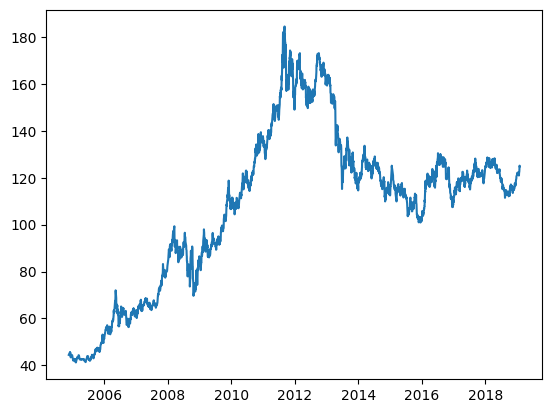

In [10]:
import matplotlib.pyplot as plt

plt.plot(df.index, df["Open"])

In [11]:
import numpy as np


def df_to_windowed_df(dataframe, n=3):
    dates = []
    X, Y = [], []

    for i in range(n, len(dataframe)):
        window = dataframe.iloc[i - n : i + 1]  # n previous + 1 target row

        if len(window) != n + 1:
            continue  # skip if not enough data

        values = window[["Open", "sentiment"]].to_numpy()
        x, y = values[:-1], values[-1][0]

        dates.append(dataframe.index[i])  # the date corresponding to the target
        X.append(x)
        Y.append(y)

    ret_df = pd.DataFrame({"Target Date": dates})

    X = np.array(X)
    for i in range(n):
        ret_df[f"Target-{n - i}"] = list(
            X[:, i]
        )  # each element is a pair: [Close, sentiment]

    ret_df["Target"] = Y

    return ret_df

In [12]:
windowed_df = df_to_windowed_df(df, n=3)
windowed_df

,Target Date,Target-3,Target-2,Target-1,Target
0,2004-11-23,"[44.43000030517578, -0.5793219208717346]","[44.4900016784668, 0.7264769300818444]","[44.75, 0.3478713557124139]",44.880001
1,2004-11-24,"[44.4900016784668, 0.7264769300818444]","[44.75, 0.3478713557124139]","[44.880001068115234, -0.8010769858956337]",44.930000
2,2004-11-29,"[44.75, 0.3478713557124139]","[44.880001068115234, -0.8010769858956337]","[44.93000030517578, 0.8925615362823012]",45.099998
3,2004-11-30,"[44.880001068115234, -0.8010769858956337]","[44.93000030517578, 0.8925615362823012]","[45.099998474121094, 0.0849677324295044]",45.369999
4,2004-12-01,"[44.93000030517578, 0.8925615362823012]","[45.099998474121094, 0.0849677324295044]","[45.369998931884766, -0.8006784543395044]",45.279999
...,...,...,...,...,...
2911,2019-01-25,"[122.27999877929688, 0.8107122350484133]","[120.95999908447266, 0.8944073989987373]","[121.16000366210938, -0.6877921521663666]",122.019997
2912,2019-01-28,"[120.95999908447266, 0.8944073989987373]","[121.16000366210938, -0.6877921521663666]","[122.0199966430664, 0.6936637610197068]",122.750000
2913,2019-01-30,"[121.16000366210938, -0.6877921521663666]","[122.0199966430664, 0.6936637610197068]","[122.75, 0.6690251007676125]",123.910004
2914,2019-01-31,"[122.0199966430664, 0.6936637610197068]","[122.75, 0.6690251007676125]","[123.91000366210938, 0.7154975235462189]",125.180000


In [13]:
df

,Open,sentiment
Date,,
2004-11-18,44.430000,-0.579322
2004-11-19,44.490002,0.726477
2004-11-22,44.750000,0.347871
2004-11-23,44.880001,-0.801077
2004-11-24,44.930000,0.892562
...,...,...
2019-01-25,122.019997,0.693664
2019-01-28,122.750000,0.669025
2019-01-30,123.910004,0.715498


In [14]:
def windowed_df_to_date_X_y(windowed_dataframe):
    dates = windowed_dataframe["Target Date"].to_numpy()

    feature_cols = windowed_dataframe.columns[1:-1]

    X = []
    for _, row in windowed_dataframe[feature_cols].iterrows():
        # Each val is a [Close, Sentiment] pair
        values = [val for val in row]  # Keep as 2D structure
        X.append(values)

    X = np.array(X)  # Shape will be (num_rows, n, 2)
    Y = windowed_dataframe["Target"].to_numpy()

    return dates, X.astype(np.float32), Y.astype(np.float32)


dates, X, y = windowed_df_to_date_X_y(windowed_df)

# check all the shapes
dates.shape, X.shape, y.shape

((2916,), (2916, 3, 2), (2916,))

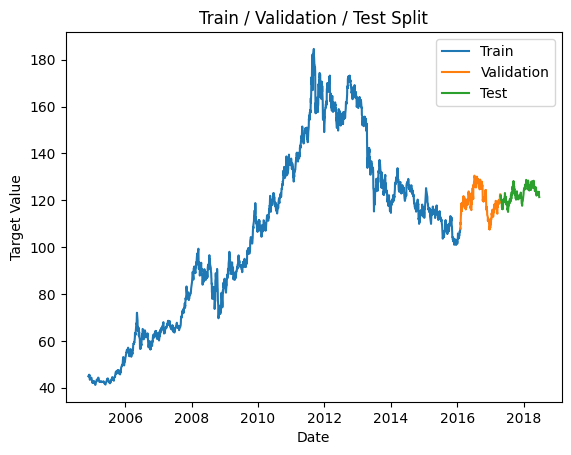

In [ ]:
# training part
q_75 = int(len(dates) * 0.75)

# validation part
q_85 = int(len(dates) * 0.85)

# testing part
q_95 = int(len(dates) * 0.95)

dates_train, X_train, y_train = dates[:q_75], X[:q_75], y[:q_75]
dates_val, X_val, y_val = dates[q_75:q_85], X[q_75:q_85], y[q_75:q_85]
dates_test, X_test, y_test = dates[q_85:q_95], X[q_85:q_95], y[q_85:q_95]
dates_hold, X_hold, y_hold = dates[q_95:], X[q_95:], y[q_95:]

plt.plot(dates_train, y_train)
plt.plot(dates_val, y_val)
plt.plot(dates_test, y_test)

plt.legend(["Train", "Validation", "Test"])
plt.xlabel("Date")
plt.ylabel("Target Value")
plt.title("Train / Validation / Test Split")
plt.show()

In [16]:
X_train

array([[[ 44.43      ,  -0.5793219 ],
        [ 44.49      ,   0.7264769 ],
        [ 44.75      ,   0.34787136]],

       [[ 44.49      ,   0.7264769 ],
        [ 44.75      ,   0.34787136],
        [ 44.88      ,  -0.801077  ]],

       [[ 44.75      ,   0.34787136],
        [ 44.88      ,  -0.801077  ],
        [ 44.93      ,   0.89256155]],

       ...,

       [[105.76      ,   0.5046343 ],
        [106.32      ,   0.45507243],
        [106.86      ,   0.57726234]],

       [[106.32      ,   0.45507243],
        [106.86      ,   0.57726234],
        [106.55      ,  -0.29270324]],

       [[106.86      ,   0.57726234],
        [106.55      ,  -0.29270324],
        [106.61      ,   0.37641606]]], dtype=float32)

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers

model = Sequential(
    [
        layers.Input((3, 2)),  # window size = 3, feature = 2
        layers.LSTM(64),
        layers.Dense(32, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1),
    ]
)  # since the output we want is just 1

model.compile(
    loss="mse", optimizer=Adam(learning_rate=0.001), metrics=["mean_absolute_error"]
)

model.fit(
    X_train, y_train, validation_data=(X_val, y_val), epochs=100
)  # 100 runs through the dataset

Epoch 1/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12831.8057 - mean_absolute_error: 107.1201 - val_loss: 7951.1426 - val_mean_absolute_error: 88.9962
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4273.8892 - mean_absolute_error: 54.4608 - val_loss: 48.9864 - val_mean_absolute_error: 5.8077
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 403.2723 - mean_absolute_error: 13.8927 - val_loss: 2.7074 - val_mean_absolute_error: 1.3073
Epoch 4/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 9.1283 - mean_absolute_error: 1.9076 - val_loss: 1.8858 - val_mean_absolute_error: 1.0332
Epoch 5/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4.2232 - mean_absolute_error: 1.3864 - val_loss: 1.9083 - val_mean_absolute_error: 1.0986
Epoch 6/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.3151 - mean_absolute_error: 1.2857 - val_loss: 1.6208 - val_mean_absolute_error: 0.9389
Epoch 7/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.9052 - mean_absolute_error:

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


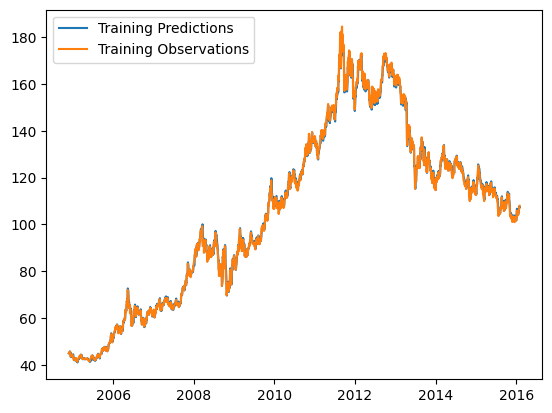

In [18]:
train_predictions = model.predict(X_train).flatten()

plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.legend(["Training Predictions", "Training Observations"])

In [19]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    explained_variance_score,
)
import numpy as np

mae = mean_absolute_error(y_train, train_predictions)
mse = mean_squared_error(y_train, train_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, train_predictions)
mape = mean_absolute_percentage_error(y_train, train_predictions)
explained_var = explained_variance_score(y_train, train_predictions)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.4f}")
print(f"Explained Variance: {explained_var:.4f}")

MAE: 1.0786
MSE: 2.3211
RMSE: 1.5235
R² Score: 0.9983
MAPE: 0.0101
Explained Variance: 0.9983


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


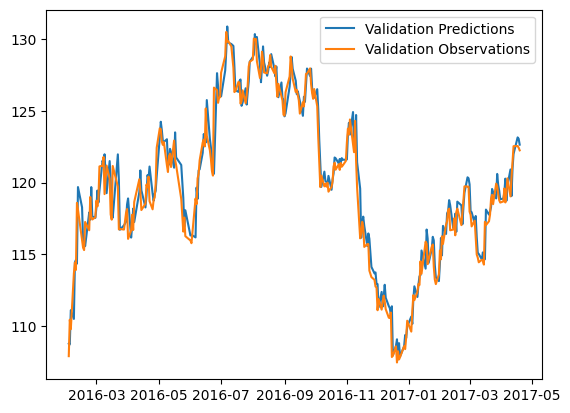

In [20]:
val_predictions = model.predict(X_val).flatten()

plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.legend(["Validation Predictions", "Validation Observations"])

In [21]:
mae = mean_absolute_error(y_val, val_predictions)
mse = mean_squared_error(y_val, val_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, val_predictions)
mape = mean_absolute_percentage_error(y_val, val_predictions)
explained_var = explained_variance_score(y_val, val_predictions)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.4f}")
print(f"Explained Variance: {explained_var:.4f}")

MAE: 0.9272
MSE: 1.5096
RMSE: 1.2287
R² Score: 0.9490
MAPE: 0.0078
Explained Variance: 0.9513


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


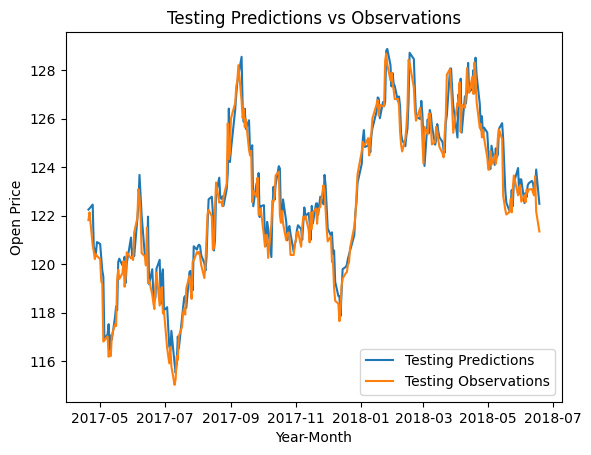

In [ ]:
test_predictions = model.predict(X_test).flatten()

plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(["Testing Predictions", "Testing Observations"])
plt.xlabel("Year-Month")  # x-axis label
plt.ylabel("Open Price")  # y-axis label
plt.title("Testing Predictions vs Observations")
plt.show()

In [23]:
mae = mean_absolute_error(y_test, test_predictions)
mse = mean_squared_error(y_test, test_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, test_predictions)
mape = mean_absolute_percentage_error(y_test, test_predictions)
explained_var = explained_variance_score(y_test, test_predictions)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.4f}")
print(f"Explained Variance: {explained_var:.4f}")

MAE: 0.6211
MSE: 0.6435
RMSE: 0.8022
R² Score: 0.9354
MAPE: 0.0051
Explained Variance: 0.9412


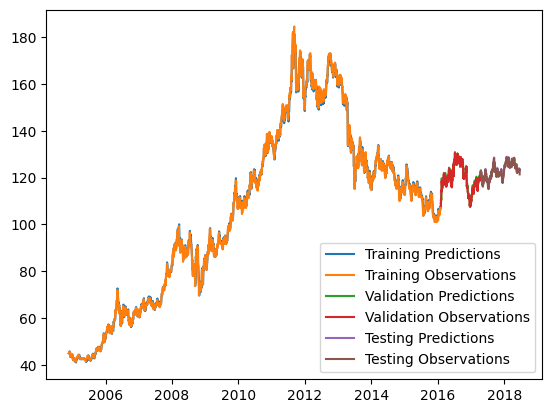

In [24]:
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(
    [
        "Training Predictions",
        "Training Observations",
        "Validation Predictions",
        "Validation Observations",
        "Testing Predictions",
        "Testing Observations",
    ]
)

In [25]:
from copy import deepcopy

recursive_predictions = []
recursive_dates = np.concatenate([dates_val, dates_test])

for target_date in recursive_dates:
    last_window = deepcopy(X_train[-1])
    next_prediction = model.predict(np.array([last_window])).flatten()
    recursive_predictions.append(next_prediction)
    last_window[-1] = next_prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━

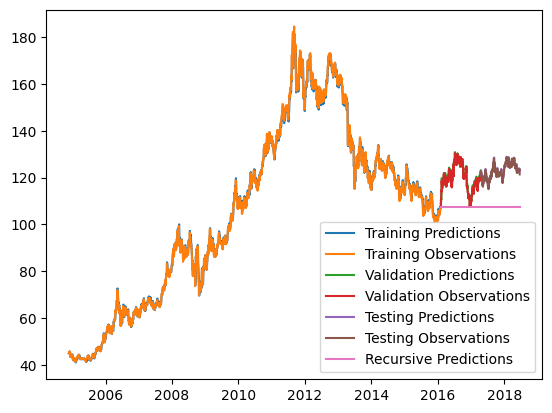

In [26]:
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.plot(recursive_dates, recursive_predictions)
plt.legend(
    [
        "Training Predictions",
        "Training Observations",
        "Validation Predictions",
        "Validation Observations",
        "Testing Predictions",
        "Testing Observations",
        "Recursive Predictions",
    ]
)